# **1. Import Library**


Pada tahap ini dilakukan import seluruh library yang diperlukan selama proses analisis data, preprocessing, pembangunan model machine learning, serta evaluasi model.

In [21]:
# Import Library

# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Pengaturan visualisasi
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Agar output angka lebih rapi
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)



---


# **2. Load Dataset**

Pada tahap ini dilakukan proses memuat dataset ke dalam lingkungan kerja menggunakan library *Pandas*. Setelah dataset berhasil dimuat, dilakukan pemeriksaan awal untuk memastikan data dapat dibaca dengan baik serta mengetahui ukuran dataset yang akan digunakan pada proses analisis selanjutnya.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving obesity_data.csv to obesity_data.csv


In [4]:
# Membaca dataset
df = pd.read_csv("obesity_data.csv")

# Menampilkan 5 data pertama
print("===== 5 Data Pertama =====")
display(df.head())

# Menampilkan 5 data terakhir
print("===== 5 Data Terakhir =====")
display(df.tail())

# Menampilkan ukuran dataset
print("Jumlah Baris dan Kolom :", df.shape)

===== 5 Data Pertama =====


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,Male,173.575262,71.982051,23.891783,4,Normal weight
1,69,Male,164.127306,89.959256,33.395209,2,Obese
2,46,Female,168.072202,72.930629,25.817737,4,Overweight
3,32,Male,168.459633,84.886912,29.912247,3,Overweight
4,60,Male,183.568568,69.038945,20.487903,3,Normal weight


===== 5 Data Terakhir =====


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
995,18,Male,155.588674,64.103182,26.480345,4,Overweight
996,35,Female,165.076490,97.639771,35.830783,1,Obese
997,49,Female,156.570956,78.804284,32.146036,1,Obese
998,64,Male,164.192222,57.978115,21.505965,4,Normal weight
999,66,Female,178.537130,74.962164,23.517168,1,Normal weight


Jumlah Baris dan Kolom : (1000, 7)




---


# **3. Data Understanding**

Pada tahap ini dilakukan analisis awal terhadap dataset untuk memahami karakteristik data yang digunakan. Analisis meliputi informasi umum dataset, tipe data setiap atribut, statistik deskriptif, serta distribusi kelas pada variabel target.


In [5]:
# Informasi Dataset

print("===== Informasi Dataset =====")
df.info()

===== Informasi Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Gender                 1000 non-null   object 
 2   Height                 1000 non-null   float64
 3   Weight                 1000 non-null   float64
 4   BMI                    1000 non-null   float64
 5   PhysicalActivityLevel  1000 non-null   int64  
 6   ObesityCategory        1000 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 54.8+ KB


In [6]:
# Statistik Deskriptif Data Numerik

print("===== Statistik Deskriptif =====")
display(df.describe())

===== Statistik Deskriptif =====


,Age,Height,Weight,BMI,PhysicalActivityLevel
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.857000,170.052417,71.205769,24.888317,2.534000
std,18.114267,10.309971,15.509849,6.193912,1.116284
min,18.000000,136.115719,26.065730,8.470572,1.000000
25%,35.000000,163.514205,61.129629,20.918068,2.000000
50%,50.000000,169.801665,71.929072,24.698647,3.000000
75%,66.000000,177.353596,81.133746,28.732132,4.000000
max,79.000000,201.419670,118.907366,50.791898,4.000000


In [7]:
# Statistik Data Kategorikal

print("===== Statistik Data Kategorikal =====")
display(df.describe(include='object'))

===== Statistik Data Kategorikal =====


,Gender,ObesityCategory
count,1000,1000
unique,2,4
top,Male,Normal weight
freq,523,371


In [10]:
# Jumlah Nilai Unik Setiap Kolom

print("===== Jumlah Nilai Unik =====")
display(df.nunique())

===== Jumlah Nilai Unik =====


,0
Age,62
Gender,2
Height,1000
Weight,1000
BMI,1000
PhysicalActivityLevel,4
ObesityCategory,4


In [11]:
# Distribusi Target Klasifikasi

print("===== Distribusi Target =====")
display(df["ObesityCategory"].value_counts())

===== Distribusi Target =====


,count
ObesityCategory,
Normal weight,371
Overweight,295
Obese,191
Underweight,143


In [12]:
# Menampilkan Nama Kolom Dataset

print("===== Nama Kolom Dataset =====")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

===== Nama Kolom Dataset =====
1. Age
2. Gender
3. Height
4. Weight
5. BMI
6. PhysicalActivityLevel
7. ObesityCategory




---
# **4. Exploratory Data Analysis (EDA)**


Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data melalui visualisasi. Tahap ini bertujuan untuk mengetahui distribusi data, hubungan antar variabel, keseimbangan kelas target, serta memperoleh insight awal yang dapat digunakan sebagai dasar dalam proses pemodelan.

### **4.1 Distribusi Fitur Numerik**


---



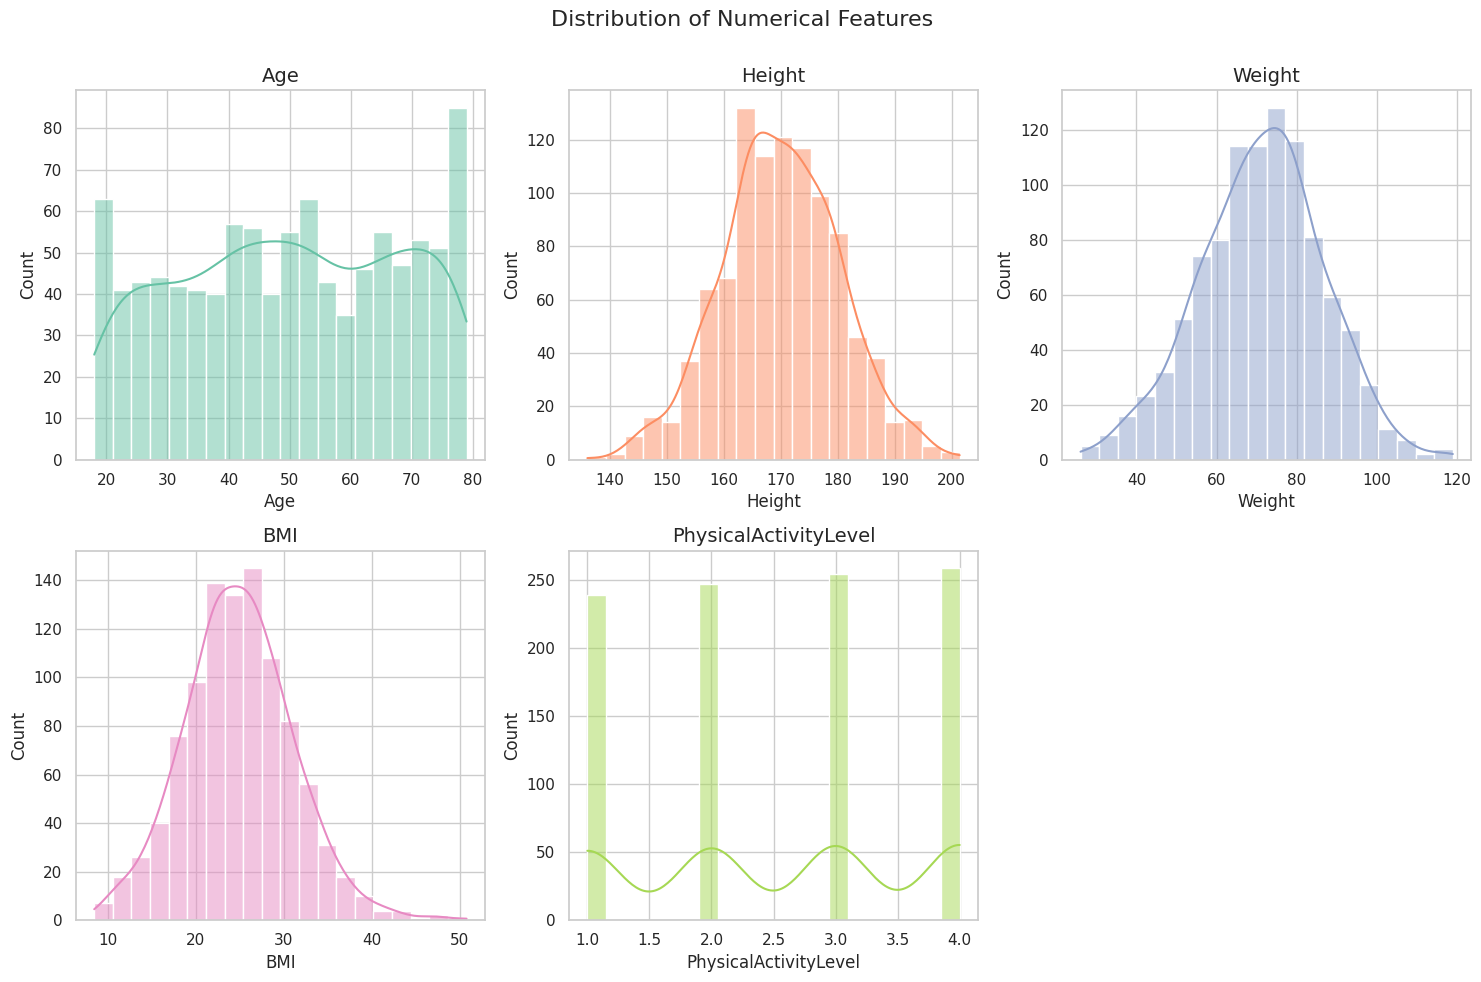

In [13]:
numerical_cols = ['Age', 'Height', 'Weight', 'BMI', 'PhysicalActivityLevel']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color=sns.color_palette("Set2")[i-1], bins=20)
    plt.title(f'{col}', fontsize=14)
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust title spacing
plt.show()

### **4.2 Distribusi Target**


---



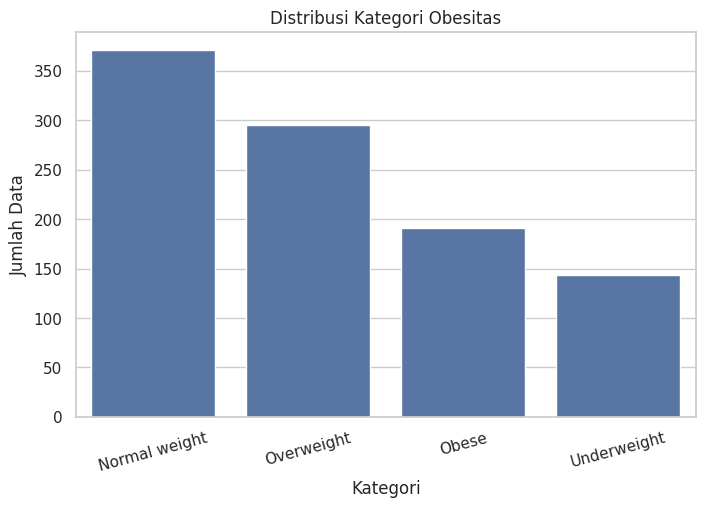

In [14]:
# Distribusi Target Klasifikasi

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ObesityCategory',
    order=df['ObesityCategory'].value_counts().index
)

plt.title("Distribusi Kategori Obesitas")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")

plt.xticks(rotation=15)

plt.show()

### **4.3 Distribusi Gender**

---



/tmp/ipykernel_1490/2086006170.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


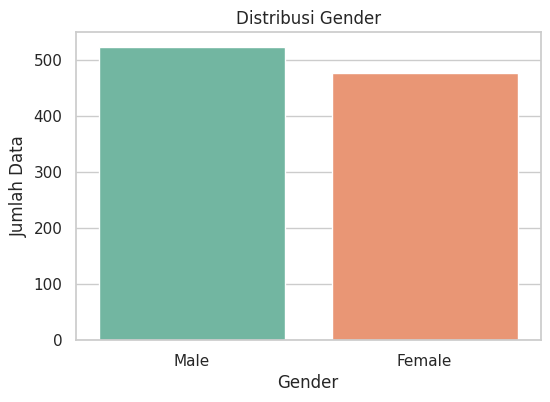

In [15]:
# Distribusi Gender

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df,
    palette='Set2'
)

plt.title('Distribusi Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah Data')

plt.show()

### **4.4 Heatmap Korelasi**


---



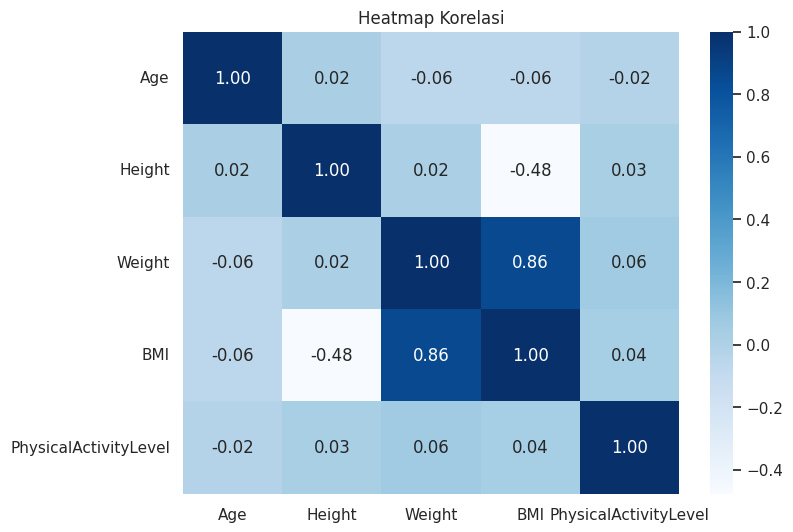

In [16]:
# Korelasi Antar Variabel Numerik

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title("Heatmap Korelasi")

plt.show()



### **4.5 Hubungan BMI dan Berat Badan**


---


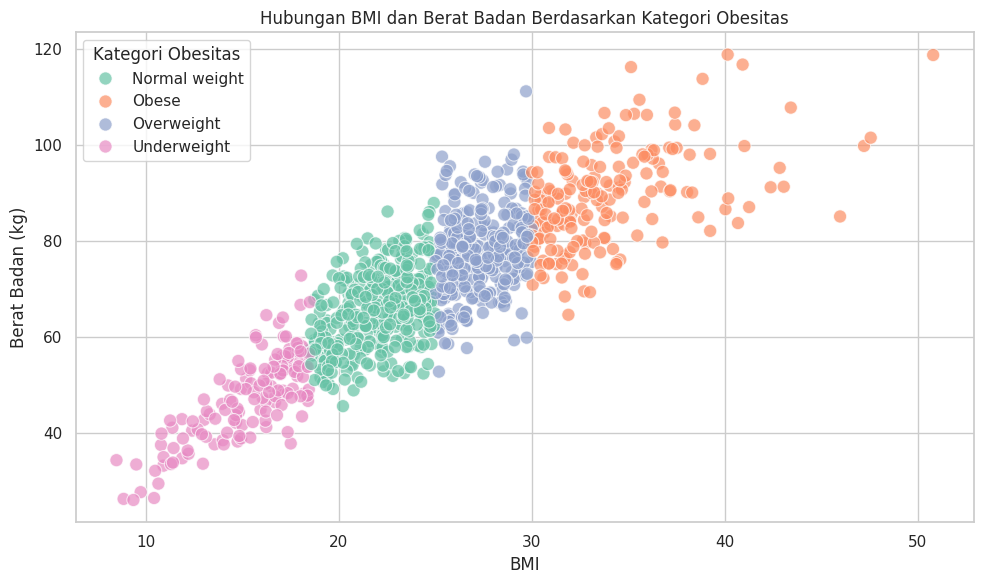

In [ ]:
# Hubungan BMI dan Berat Badan

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="BMI",
    y="Weight",
    hue="ObesityCategory",
    palette="Set2",
    s=90,
    alpha=0.7
)

plt.title("Hubungan BMI dan Berat Badan Berdasarkan Kategori Obesitas")
plt.xlabel("BMI")
plt.ylabel("Berat Badan (kg)")

plt.legend(title="Kategori Obesitas")

plt.tight_layout()

plt.show()



---


# **5. Data Preparation**

Pada tahap ini dilakukan proses persiapan data sebelum digunakan dalam pemodelan Machine Learning. Tahapan yang dilakukan meliputi pemeriksaan missing value dan data duplikat, transformasi data kategorikal menjadi data numerik (label encoding), pemilihan fitur (feature selection), normalisasi data numerik, serta pemisahan dataset menjadi data latih (training set) dan data uji (testing set). Berdasarkan hasil pemeriksaan, dataset tidak memiliki missing value maupun data duplikat sehingga tidak diperlukan proses pembersihan data lebih lanjut.

Selain itu, atribut BMI tidak digunakan sebagai fitur pada proses pemodelan karena memiliki hubungan yang sangat erat dengan variabel target (ObesityCategory) dan dihitung berdasarkan atribut tinggi badan serta berat badan. Penggunaan atribut tersebut berpotensi menyebabkan data leakage sehingga dapat menghasilkan performa model yang tidak merepresentasikan kemampuan klasifikasi secara objektif. Oleh karena itu, proses pemodelan hanya menggunakan atribut Age, Gender, Height, Weight, dan PhysicalActivityLevel sebagai variabel masukan.

In [17]:
# Mengecek Missing Value

print("===== Missing Value =====")
display(df.isnull().sum())

===== Missing Value =====


,0
Age,0
Gender,0
Height,0
Weight,0
BMI,0
PhysicalActivityLevel,0
ObesityCategory,0


In [18]:
# Mengecek Data Duplikat

duplicate = df.duplicated().sum()

print("Jumlah Data Duplikat :", duplicate)

Jumlah Data Duplikat : 0


In [22]:
# Label Encoding

# Membuat salinan dataset
df_prepared = df.copy()

# Encoder untuk Gender
gender_encoder = LabelEncoder()

# Encoder untuk Target
target_encoder = LabelEncoder()

# Encoding Gender
df_prepared["Gender"] = gender_encoder.fit_transform(df_prepared["Gender"])

# Encoding Target
df_prepared["ObesityCategory"] = target_encoder.fit_transform(
    df_prepared["ObesityCategory"]
)

print("===== Dataset Setelah Encoding =====")

display(df_prepared.head())

===== Dataset Setelah Encoding =====


,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,1,173.575262,71.982051,23.891783,4,0
1,69,1,164.127306,89.959256,33.395209,2,1
2,46,0,168.072202,72.930629,25.817737,4,2
3,32,1,168.459633,84.886912,29.912247,3,2
4,60,1,183.568568,69.038945,20.487903,3,0


In [23]:
# Mapping Hasil Label Encoding

print("Mapping Gender")
for i, label in enumerate(gender_encoder.classes_):
    print(f"{label} -> {i}")

print()

print("Mapping Obesity Category")
for i, label in enumerate(target_encoder.classes_):
    print(f"{label} -> {i}")

Mapping Gender
Female -> 0
Male -> 1

Mapping Obesity Category
Normal weight -> 0
Obese -> 1
Overweight -> 2
Underweight -> 3


In [24]:
# Informasi Dataset Setelah Encoding

print("===== Informasi Dataset Setelah Encoding =====")

df_prepared.info()

===== Informasi Dataset Setelah Encoding =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Gender                 1000 non-null   int64  
 2   Height                 1000 non-null   float64
 3   Weight                 1000 non-null   float64
 4   BMI                    1000 non-null   float64
 5   PhysicalActivityLevel  1000 non-null   int64  
 6   ObesityCategory        1000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 54.8 KB


In [25]:
# Memisahkan Feature dan Target
# BMI dihapus dari feature untuk menghindari data leakage
X = df_prepared.drop(["ObesityCategory", "BMI"], axis=1)

y = df_prepared["ObesityCategory"]

print("Ukuran Feature :", X.shape)
print("Ukuran Target  :", y.shape)

print("\nFeature yang digunakan:")
print(X.columns.tolist())

Ukuran Feature : (1000, 5)
Ukuran Target  : (1000,)

Feature yang digunakan:
['Age', 'Gender', 'Height', 'Weight', 'PhysicalActivityLevel']


In [26]:
# Normalisasi Data Numerik
# Menentukan kolom numerik yang akan dinormalisasi
numeric_columns = ["Age", "Height", "Weight", "PhysicalActivityLevel"]

# Membuat salinan feature
X_scaled = X.copy()

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Melakukan normalisasi
X_scaled[numeric_columns] = scaler.fit_transform(X_scaled[numeric_columns])

print("===== Data Setelah Normalisasi =====")
display(X_scaled.head())

===== Data Setelah Normalisasi =====


,Age,Gender,Height,Weight,PhysicalActivityLevel
0,0.339295,1,0.341864,0.050076,1.313943
1,1.057320,1,-0.574985,1.209739,-0.478612
2,-0.213033,0,-0.192164,0.111266,1.313943
3,-0.986291,1,-0.154567,0.882535,0.417665
4,0.560226,1,1.311635,-0.139776,0.417665




---

# **6. Split Dataset**

Pada tahap ini dataset dibagi menjadi data latih (*training data*) dan data uji (*testing data*). Pembagian dilakukan dengan rasio **80:20**, di mana **80%** data digunakan untuk melatih model dan **20%** data digunakan untuk menguji performa model.

Parameter `stratify=y` digunakan agar proporsi setiap kategori obesitas tetap seimbang pada data latih maupun data uji.

In [27]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("===== Hasil Split Dataset =====")

print(f"Data Training Feature : {X_train.shape}")
print(f"Data Testing Feature  : {X_test.shape}")
print(f"Data Training Target  : {y_train.shape}")
print(f"Data Testing Target   : {y_test.shape}")

===== Hasil Split Dataset =====
Data Training Feature : (800, 5)
Data Testing Feature  : (200, 5)
Data Training Target  : (800,)
Data Testing Target   : (200,)


In [28]:
# Distribusi Target Setelah Split Dataset

print("===== Distribusi Target Training =====")
display(y_train.value_counts())

print()

print("===== Distribusi Target Testing =====")
display(y_test.value_counts())

===== Distribusi Target Training =====


,count
ObesityCategory,
0,297
2,236
1,153
3,114



===== Distribusi Target Testing =====


,count
ObesityCategory,
0,74
2,59
1,38
3,29




---

# **7. Model 1 - Decision Tree**

Pada tahap ini dilakukan pembangunan model klasifikasi menggunakan algoritma **Decision Tree**. Model dilatih menggunakan data latih (*training data*) dan kemudian diuji menggunakan data uji (*testing data*). Selanjutnya dilakukan evaluasi performa model menggunakan beberapa metrik evaluasi, yaitu **Accuracy**, **Confusion Matrix**, **Precision**, **Recall**, dan **F1-Score**.

### **7.1 Training Model**


---



In [29]:
# Training Model Decision Tree

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Model Decision Tree berhasil dilatih.")

Model Decision Tree berhasil dilatih.


### **7.2 Prediksi**


---



In [30]:
# Prediksi Decision Tree

y_pred_dt = decision_tree.predict(X_test)

print("Prediksi berhasil dilakukan.")

Prediksi berhasil dilakukan.


### **7.3 Fungsi Evaluasi**


---



In [31]:
# Fungsi Evaluasi Model

def evaluate_model(model_name, y_test, y_pred):

    print("=" * 50)
    print(f"Evaluasi Model : {model_name}")
    print("=" * 50)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

Evaluasi Model : Decision Tree
Accuracy  : 0.9150
Precision : 0.9161
Recall    : 0.9150
F1-Score  : 0.9147
               precision    recall  f1-score   support

Normal weight       0.90      0.96      0.93        74
        Obese       0.92      0.92      0.92        38
   Overweight       0.91      0.88      0.90        59
  Underweight       0.96      0.86      0.91        29

     accuracy                           0.92       200
    macro avg       0.92      0.91      0.91       200
 weighted avg       0.92      0.92      0.91       200

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        74
           1       0.92      0.92      0.92        38
           2       0.91      0.88      0.90        59
           3       0.96      0.86      0.91        29

    accuracy                           0.92       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.92      0.91       200



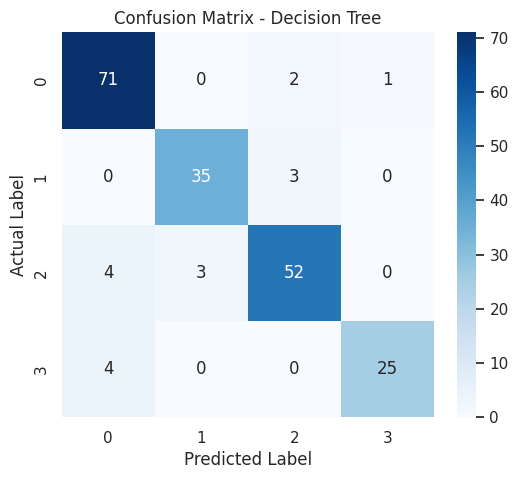

In [32]:
# Evaluasi Decision Tree

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)



---


# **8. Model 2 - Random Forest**

Pada tahap ini dilakukan pembangunan model klasifikasi menggunakan algoritma **Random Forest**. Model dilatih menggunakan data latih (*training data*) dan dievaluasi menggunakan data uji (*testing data*). Hasil evaluasi kemudian dibandingkan dengan model **Decision Tree** untuk mengetahui model dengan performa terbaik.

### **8.1 Training Model Random Forest**


---



In [33]:
# Training Model Random Forest

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


### **8.2 Prediksi**


---



In [34]:
# Prediksi Random Forest

y_pred_rf = random_forest.predict(X_test)

print("Prediksi berhasil dilakukan.")

Prediksi berhasil dilakukan.


### **8.3 Evaluasi Random Forest**


---



Evaluasi Model : Random Forest
Accuracy  : 0.9350
Precision : 0.9378
Recall    : 0.9350
F1-Score  : 0.9351
               precision    recall  f1-score   support

Normal weight       0.89      0.97      0.93        74
        Obese       1.00      0.95      0.97        38
   Overweight       0.95      0.92      0.93        59
  Underweight       0.96      0.86      0.91        29

     accuracy                           0.94       200
    macro avg       0.95      0.92      0.94       200
 weighted avg       0.94      0.94      0.94       200

              precision    recall  f1-score   support

           0       0.89      0.97      0.93        74
           1       1.00      0.95      0.97        38
           2       0.95      0.92      0.93        59
           3       0.96      0.86      0.91        29

    accuracy                           0.94       200
   macro avg       0.95      0.92      0.94       200
weighted avg       0.94      0.94      0.94       200



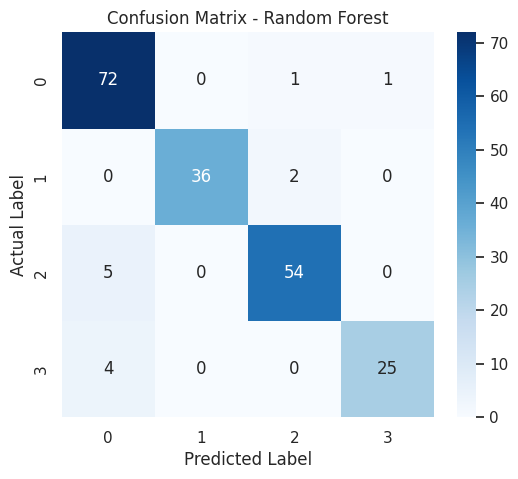

In [35]:
# Evaluasi Random Forest

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)



---


# **9. Perbandingan Model**

Pada tahap ini dilakukan perbandingan performa antara model **Decision Tree** dan **Random Forest** berdasarkan metrik evaluasi yang telah diperoleh. Perbandingan dilakukan menggunakan nilai **Accuracy**, **Precision**, **Recall**, dan **F1-Score** untuk menentukan model dengan performa terbaik.

In [ ]:
# Perbandingan Model

# Menghitung metrik Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

# Menghitung metrik Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Membuat tabel perbandingan
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1-Score": [dt_f1, rf_f1]
})

# Mengubah ke persen
comparison.iloc[:, 1:] = comparison.iloc[:, 1:] * 100

# Membulatkan 2 angka di belakang koma
comparison = comparison.round(2)

display(comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,91.5,91.61,91.5,91.47
1,Random Forest,93.5,93.78,93.5,93.51


---
# **10. Kesimpulan**

Berdasarkan hasil pemodelan yang telah dilakukan, algoritma **Random Forest** memperoleh performa yang lebih baik dibandingkan **Decision Tree**. Hal ini ditunjukkan oleh nilai **Accuracy**, **Precision**, **Recall**, dan **F1-Score** yang lebih tinggi.

Dengan demikian, algoritma **Random Forest** dipilih sebagai model terbaik untuk melakukan klasifikasi kategori obesitas pada dataset yang digunakan karena mampu memberikan hasil prediksi yang lebih akurat dan stabil.

Pada proses pemodelan, atribut BMI tidak digunakan sebagai fitur karena memiliki hubungan langsung dengan kategori obesitas. Penghapusan atribut tersebut bertujuan mengurangi potensi data leakage sehingga hasil evaluasi model lebih merepresentasikan kemampuan prediksi yang sebenarnya.